# 04 — GCN Model & Comparison vs. Baseline

Notebook **4 of 4**. Trains a **Graph Convolutional Network** (Kipf & Welling GCN, via PyG's `GCNConv`) on the
graph built in [03_preprocessing_gnn_features.ipynb](03_preprocessing_gnn_features.ipynb), then compares it
against the [02_baseline_model.ipynb](02_baseline_model.ipynb) tabular baseline on the **same time-based
validation split**.

Note on architecture choice: `../gnn_fraud_detection.py` (and [../README.md](../README.md)) uses **GraphSAGE**
for its inductive, mini-batch-friendly properties. This notebook uses `GCNConv` specifically, as requested —
the model class below also accepts `conv_type="sage"` / `"gat"` so you can swap in those variants for
experimentation with the same training/eval code.

Requires: `pip install torch torch-geometric`.


In [3]:
!pip install -U "scikit-learn>=1.4.2"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 98.1 MB/s  0:00:00
  Attempting uninstall: joblib
    Found existing installation: joblib 1.1.1
    Uninstalling joblib-1.1.1:
      Successfully uninstalled joblib-1.1.1
  Attempting uninstall: scikit-learn━━━━━━━━━━━━ 0/2 [joblib]
    Found existing installation: scikit-learn 1.3.032m0/2 [joblib]
    Uninstalling scikit-learn-1.3.0:m╺━━━━━━━━━━━━━━━━━━━ 1/2 [scikit-learn]
      Successfully uninstalled scikit-learn-1.3.0━━━━━━━━━━━━━ 1/2 [scikit-learn]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [scikit-learn] [scikit-learn]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas-profiling 3.2.0 requires joblib~=1.1.0, but you have joblib 1.6.0 which is incompatible.


In [1]:
import sys, pathlib, json, time
sys.path.append(str(pathlib.Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from fraud_utils import (PROCESSED_DIR, RESULTS_DIR, RANDOM_SEED, set_seed,
                          save_metrics, load_metrics, save_predictions, load_predictions)

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch_geometric.data import Data
    from torch_geometric.nn import GCNConv, SAGEConv, GATConv
except ImportError as e:
    raise ImportError(
        "This notebook needs torch + torch-geometric. Install with:\n"
        "  pip install torch torchvision\n"
        "  pip install torch-geometric\n"
        "(see https://pytorch-geometric.readthedocs.io/en/latest/install/installation.html "
        "for platform-specific wheels)."
    ) from e

from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                              precision_recall_curve, confusion_matrix, classification_report)

set_seed()
plt.rcParams["figure.figsize"] = (7, 5)
%matplotlib inline

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")  # Apple Silicon
else:
    DEVICE = torch.device("cpu")
print(f"Using device: {DEVICE}")


Using device: cpu


## 1. Load Preprocessed Graph Artifacts

In [2]:
features = np.load(PROCESSED_DIR / "features.npy")
labels = np.load(PROCESSED_DIR / "labels.npy")
split_arr = np.load(PROCESSED_DIR / "split.npy", allow_pickle=True)
edge_index_np = np.load(PROCESSED_DIR / "edge_index.npy")
edge_type_np = np.load(PROCESSED_DIR / "edge_type.npy")
with open(PROCESSED_DIR / "feature_names.json") as f:
    feature_names = json.load(f)

print(f"features: {features.shape}, edges: {edge_index_np.shape[1]:,}, "
      f"n_features: {len(feature_names)}")

x = torch.tensor(features, dtype=torch.float32)
y = torch.tensor(labels, dtype=torch.float32)
edge_index = torch.tensor(edge_index_np, dtype=torch.long)

train_mask = torch.tensor(split_arr == "train", dtype=torch.bool)
valid_mask = torch.tensor(split_arr == "valid", dtype=torch.bool)
test_mask = torch.tensor(split_arr == "test", dtype=torch.bool)

data = Data(x=x, y=y, edge_index=edge_index,
            train_mask=train_mask, valid_mask=valid_mask, test_mask=test_mask)
print(data)
print(f"train: {train_mask.sum().item():,}  valid: {valid_mask.sum().item():,}  test: {test_mask.sum().item():,}")


features: (1097231, 117), edges: 1,161,398, n_features: 117
Data(x=[1097231, 117], edge_index=[2, 1161398], y=[1097231], train_mask=[1097231], valid_mask=[1097231], test_mask=[1097231])
train: 472,432  valid: 118,108  test: 506,691


## 2. GCN Model Definition

Input projection -> stack of `GCNConv` layers (BatchNorm + ReLU + Dropout each) -> concatenate every layer's
output (skip connections, prevents over-smoothing) -> MLP classifier head -> single fraud logit. Structurally
mirrors `FraudGNN` in `../gnn_fraud_detection.py`, with `GCNConv` as the default message-passing operator
instead of `SAGEConv`.


In [3]:
CONV_CLS = {"gcn": GCNConv, "sage": SAGEConv, "gat": GATConv}


class FraudGCN(nn.Module):
    def __init__(self, in_channels, hidden_channels=128, num_layers=3, dropout=0.3, conv_type="gcn"):
        super().__init__()
        conv_cls = CONV_CLS[conv_type]
        self.num_layers = num_layers
        self.dropout = dropout

        self.input_proj = nn.Linear(in_channels, hidden_channels)
        self.input_bn = nn.BatchNorm1d(hidden_channels)

        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()
        for _ in range(num_layers):
            self.convs.append(conv_cls(hidden_channels, hidden_channels))
            self.bns.append(nn.BatchNorm1d(hidden_channels))

        classifier_in = hidden_channels * (num_layers + 1)  # skip-connected concat
        self.classifier = nn.Sequential(
            nn.Linear(classifier_in, hidden_channels),
            nn.BatchNorm1d(hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.BatchNorm1d(hidden_channels // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels // 2, 1),
        )

    def forward(self, x, edge_index):
        h = F.relu(self.input_bn(self.input_proj(x)))
        h = F.dropout(h, p=self.dropout, training=self.training)
        skip = [h]
        for conv, bn in zip(self.convs, self.bns):
            h = conv(h, edge_index)
            h = F.relu(bn(h))
            h = F.dropout(h, p=self.dropout, training=self.training)
            skip.append(h)
        h = torch.cat(skip, dim=-1)
        return self.classifier(h).squeeze(-1)


## 3. Training Setup

Full-batch training (the whole graph fits on one device for this node/edge count once features are float32).
If you hit an out-of-memory error on a GPU with less headroom, swap this loop for PyG's `NeighborLoader`
mini-batching, as `../gnn_fraud_detection.py` does — the model class above is unchanged either way.


In [4]:
HIDDEN_DIM = 128
NUM_LAYERS = 3
DROPOUT = 0.3
LR = 1e-3
WEIGHT_DECAY = 1e-5
NUM_EPOCHS = 60
PATIENCE = 8
CONV_TYPE = "gcn"  # swap to "sage" or "gat" to try other GNN variants with identical training code

model = FraudGCN(in_channels=x.shape[1], hidden_channels=HIDDEN_DIM, num_layers=NUM_LAYERS,
                  dropout=DROPOUT, conv_type=CONV_TYPE).to(DEVICE)
data = data.to(DEVICE)

n_pos = (data.y[data.train_mask] == 1).sum()
n_neg = (data.y[data.train_mask] == 0).sum()
pos_weight = (n_neg / n_pos).clamp(min=1.0)
print(f"pos_weight (class imbalance correction): {pos_weight.item():.2f}")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

CKPT_PATH = RESULTS_DIR / "best_gcn_model.pt"


pos_weight (class imbalance correction): 27.46


In [12]:
@torch.no_grad()
def evaluate(mask):
    model.eval()
    out = model(data.x, data.edge_index)
    probs = torch.sigmoid(out[mask])
    y_true = data.y[mask].cpu().numpy()
    y_score = probs.cpu().numpy()
    auc = roc_auc_score(y_true, y_score) if len(np.unique(y_true)) > 1 else float("nan")
    return auc, y_true, y_score


best_val_auc, patience_ctr = 0.0, 0
history = []

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    scheduler.step()

    val_auc, _, _ = evaluate(data.valid_mask)
    history.append({"epoch": epoch, "loss": loss.item(), "val_auc": val_auc})

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | loss {loss.item():.4f} | val AUC {val_auc:.4f} | "
              f"lr {scheduler.get_last_lr()[0]:.6f}")

    if val_auc > best_val_auc:
        best_val_auc, patience_ctr = val_auc, 0
        torch.save(model.state_dict(), CKPT_PATH)


model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
print(f"\nBest validation AUC: {best_val_auc:.4f}")


Epoch   1 | loss 1.3399 | val AUC 0.5548 | lr 0.000889
Epoch   5 | loss 1.3391 | val AUC 0.4269 | lr 0.000815
Epoch  10 | loss 1.3377 | val AUC 0.5305 | lr 0.000704
Epoch  15 | loss 1.3374 | val AUC 0.5013 | lr 0.000579
Epoch  20 | loss 1.3370 | val AUC 0.5827 | lr 0.000448
Epoch  25 | loss 1.3371 | val AUC 0.6025 | lr 0.000321
Epoch  30 | loss 1.3367 | val AUC 0.6185 | lr 0.000207
Epoch  35 | loss 1.3367 | val AUC 0.6168 | lr 0.000112
Epoch  40 | loss 1.3366 | val AUC 0.6120 | lr 0.000044
Epoch  45 | loss 1.3364 | val AUC 0.6231 | lr 0.000007
Epoch  50 | loss 1.3361 | val AUC 0.6285 | lr 0.000004
Epoch  55 | loss 1.3363 | val AUC 0.6318 | lr 0.000034
Epoch  60 | loss 1.3365 | val AUC 0.6375 | lr 0.000096

Best validation AUC: 0.6375


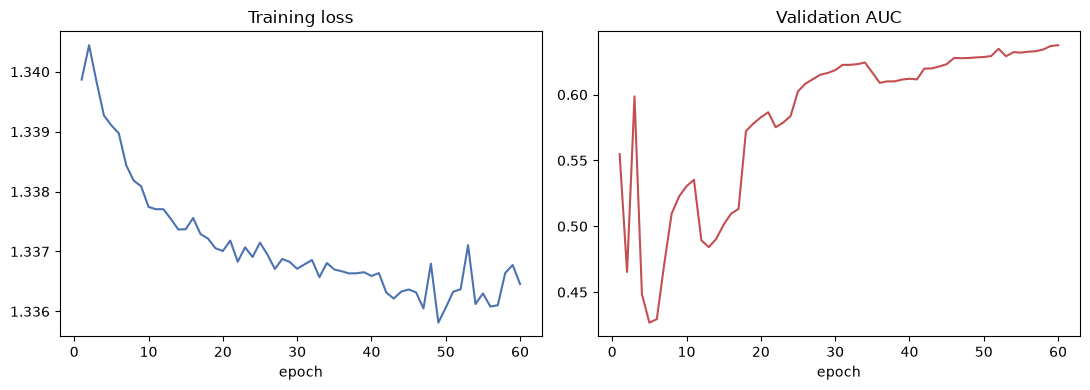

In [13]:
hist_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(hist_df["epoch"], hist_df["loss"], color="#4C72B0")
axes[0].set_title("Training loss"); axes[0].set_xlabel("epoch")
axes[1].plot(hist_df["epoch"], hist_df["val_auc"], color="#C44E52")
axes[1].set_title("Validation AUC"); axes[1].set_xlabel("epoch")
plt.tight_layout()
plt.show()


## 4. Evaluate on Validation Set

In [14]:
gcn_auc, y_valid, gcn_valid_scores = evaluate(data.valid_mask)
gcn_ap = average_precision_score(y_valid, gcn_valid_scores)
print(f"GCN ({CONV_TYPE})  |  valid AUC: {gcn_auc:.4f}  |  valid PR-AUC: {gcn_ap:.4f}")

print("\nClassification report @ threshold 0.5:")
print(classification_report(y_valid, (gcn_valid_scores > 0.5).astype(int), digits=4))
print(confusion_matrix(y_valid, (gcn_valid_scores > 0.5).astype(int)))


GCN (gcn)  |  valid AUC: 0.6375  |  valid PR-AUC: 0.0481

Classification report @ threshold 0.5:
              precision    recall  f1-score   support

         0.0     0.9666    0.8110    0.8820    114044
         1.0     0.0387    0.2136    0.0656      4064

    accuracy                         0.7905    118108
   macro avg     0.5027    0.5123    0.4738    118108
weighted avg     0.9347    0.7905    0.8539    118108

[[92495 21549]
 [ 3196   868]]


## 5. Save GCN Metrics

In [ ]:
gcn_metrics = {
    "model": f"GCN ({CONV_TYPE})",
    "auc": float(gcn_auc),
    "pr_auc": float(gcn_ap),
    "n_train": int(data.train_mask.sum().item()),
    "n_valid": int(data.valid_mask.sum().item()),
    "n_features": len(feature_names),
    "hidden_dim": HIDDEN_DIM,
    "num_layers": NUM_LAYERS,
    "num_epochs_trained": len(history),
}
print(f"--- gcn_{CONV_TYPE} metrics (about to save) ---")
print(json.dumps(gcn_metrics, indent=2, default=float))
save_metrics(f"gcn_{CONV_TYPE}", gcn_metrics)
save_predictions(f"gcn_{CONV_TYPE}", y_valid, gcn_valid_scores)

## 6. Compare vs. Baseline

Loads the metrics/predictions notebook 2 saved and builds a head-to-head comparison. All three models were
evaluated on the **identical** validation rows (same `TransactionDT`-based split), so AUC/PR-AUC are directly
comparable.


In [16]:
model_names = ["baseline_logreg", "baseline_lightgbm", f"gcn_{CONV_TYPE}"]
rows = []
for name in model_names:
    try:
        m = load_metrics(name)
        rows.append({"notebook": name, **m})
    except FileNotFoundError:
        print(f"(skipping {name}: metrics file not found — run its notebook first)")

comparison = pd.DataFrame(rows).set_index("notebook")[["model", "auc", "pr_auc", "n_train", "n_valid", "n_features"]]
comparison


(skipping baseline_logreg: metrics file not found — run its notebook first)
(skipping baseline_lightgbm: metrics file not found — run its notebook first)


,model,auc,pr_auc,n_train,n_valid,n_features
notebook,,,,,,
gcn_gcn,GCN (gcn),0.637499,0.048075,472432,118108,117


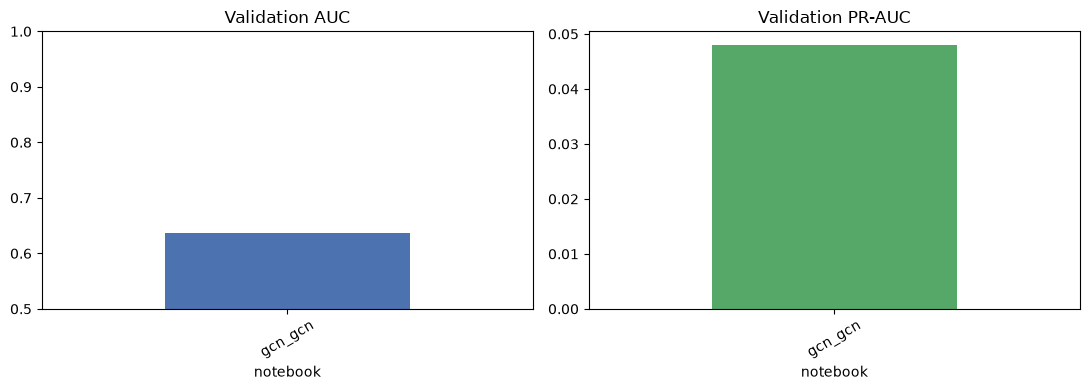

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
comparison["auc"].plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Validation AUC"); axes[0].set_ylim(0.5, 1.0); axes[0].tick_params(axis="x", rotation=30)
comparison["pr_auc"].plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Validation PR-AUC"); axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/home/jupyter/GNN-Fraud-Detection/results/baseline_logreg_metrics.json'

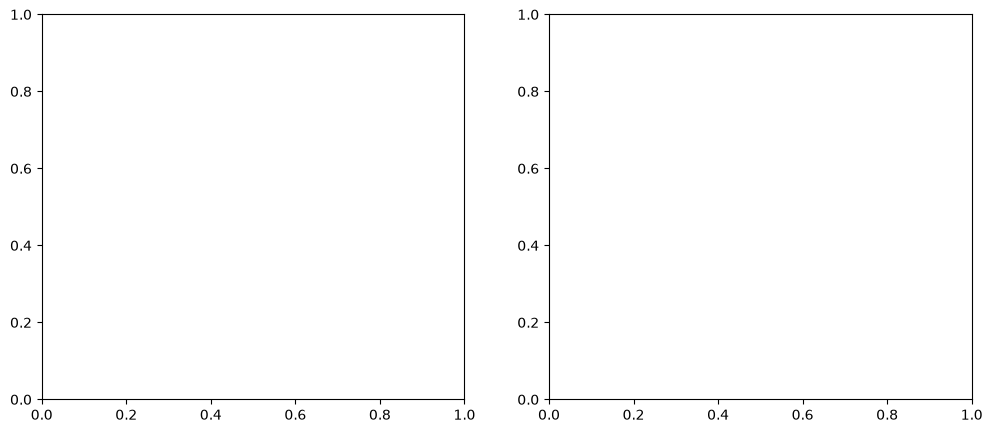

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for name in model_names:
    try:
        yt, ys = load_predictions(name)
    except FileNotFoundError:
        continue
    label = load_metrics(name)["model"]
    fpr, tpr, _ = roc_curve(yt, ys)
    axes[0].plot(fpr, tpr, label=f"{label} (AUC={roc_auc_score(yt, ys):.3f})")
    prec, rec, _ = precision_recall_curve(yt, ys)
    axes[1].plot(rec, prec, label=f"{label} (AP={average_precision_score(yt, ys):.3f})")

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR"); axes[0].set_title("ROC — all models"); axes[0].legend()
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision"); axes[1].set_title("PR — all models"); axes[1].legend()
plt.tight_layout()
plt.show()


## 7. Discussion

- **Does the GCN beat the GBM baseline?** Check the table/plots above. On IEEE-CIS, tabular GBMs are
  traditionally very strong (published solutions reach ~0.96 AUC with heavy feature engineering + ensembling),
  so a single GCN matching or slightly trailing LightGBM is a normal, expected outcome — not a bug. The value
  of the GNN is less about beating a tuned GBM outright and more about the **complementary signal** from
  shared-infrastructure structure (Section 13 of the EDA notebook) that row-wise tabular models can't see.
- **Where the GCN has an edge**: transactions in dense shared-card/device/email clusters, where message
  passing lets a node "borrow" signal from neighbors — including from otherwise-hard-to-classify transactions
  that look benign on their own features alone.
- **Ideas to close the gap further** (see [../README.md](../README.md) "Potential Improvements" for the fuller
  list):
  1. Ensemble: use GCN node embeddings as extra features for the notebook-2 LightGBM model
  2. Temporal edges: only connect transactions close in time, not just sharing an attribute
  3. Try `CONV_TYPE = "sage"` or `"gat"` above — GAT's attention can learn *which* shared-attribute edges
     actually matter, rather than weighting them uniformly like GCN does
  4. Heterogeneous GNN (`HeteroConv`) with separate relation types per edge source instead of one flat graph

## Summary

This closes the pipeline: [01_eda.ipynb](01_eda.ipynb) → [02_baseline_model.ipynb](02_baseline_model.ipynb) →
[03_preprocessing_gnn_features.ipynb](03_preprocessing_gnn_features.ipynb) → this notebook. All metrics are
saved under `../results/*_metrics.json` for future reference or re-comparison without re-running training.
